In [1]:
import h5py
from shape_info import *
import pandas as pd

In [2]:
filename = "TNG300-1_HaloHistory_MBP_snap99.hdf5"

In [3]:
filename_old = "TNG300-1_z0.00_gas.hdf5"

In [4]:
get_halo_keys(filename_old)

['halo_000000',
 'halo_000001',
 'halo_000002',
 'halo_000003',
 'halo_000004',
 'halo_000005',
 'halo_000006',
 'halo_000007',
 'halo_000008',
 'halo_000009',
 'halo_000010',
 'halo_000011',
 'halo_000012',
 'halo_000013',
 'halo_000014',
 'halo_000015',
 'halo_000016',
 'halo_000017',
 'halo_000018',
 'halo_000019',
 'halo_000020',
 'halo_000021',
 'halo_000022',
 'halo_000023',
 'halo_000024',
 'halo_000025',
 'halo_000026',
 'halo_000027',
 'halo_000028',
 'halo_000029',
 'halo_000030',
 'halo_000031',
 'halo_000032',
 'halo_000033',
 'halo_000034',
 'halo_000035',
 'halo_000036',
 'halo_000037',
 'halo_000038',
 'halo_000039',
 'halo_000040',
 'halo_000041',
 'halo_000042',
 'halo_000043',
 'halo_000044',
 'halo_000045',
 'halo_000046',
 'halo_000047',
 'halo_000048',
 'halo_000049',
 'halo_000050',
 'halo_000051',
 'halo_000052',
 'halo_000053',
 'halo_000054',
 'halo_000055',
 'halo_000056',
 'halo_000057',
 'halo_000058',
 'halo_000059',
 'halo_000060',
 'halo_000061',
 'halo_0

In [6]:
masses_old = attribute_read(filename_old, get_halo_keys(filename_old), 'M200_Msun')

In [7]:
print(len(masses_old))

3733


In [8]:
halos_df = pd.read_hdf(filename, key = 'Halos')
print(halos_df)

        HaloID  SubhaloID  SubhaloID_DMO  SubhaloID_LastDesc  Central  Main  \
0            0          0              0                   0      1.0   1.0   
1            1      11748          20483               11748      1.0   1.0   
2            2      17908          28634               17908      1.0   1.0   
3            3      22736          35096               22736      1.0   1.0   
4            4      27878          41427               27878      1.0   1.0   
...        ...        ...            ...                 ...      ...   ...   
13638   567662    3165689        3776508             3165689      1.0   1.0   
13639  1491406    4296744        4984321             4296744      1.0   1.0   
13640  1893046    4735823         323993             4735823      1.0   1.0   
13641  2390662    5259302        5768633             5259302      1.0   1.0   
13642  4009511    6792705         306095             6792705      1.0   1.0   

        Mvir_TNG     Rvir_TNG          pos_x       

In [3]:
len(halos_df['Mvir_TNG'].values)

13643

In [9]:
Halos = pd.read_hdf(filename, key = 'Halos').to_numpy()
print(Halos)

[[0 0 0 ... 7.336860824510281e-05 13.104929419552514 'Success']
 [1 11748 20483 ... 5.3143595735855655e-05 12.886462986651077 'Success']
 [2 17908 28634 ... -1.9522154738417314e-05 12.935548163749724 'Success']
 ...
 [1893046 4735823 323993 ... 0.0010631122899490341 8.590736768994686
  'Success']
 [2390662 5259302 5768633 ... nan nan 'Success']
 [4009511 6792705 306095 ... nan nan 'Check100DMpart']]


In [10]:
halos_df['HaloID'].values

array([      0,       1,       2, ..., 1893046, 2390662, 4009511],
      dtype=int32)

In [24]:
mass = halos_df['M200c'].values

In [25]:
print(mass)

[15.17981662 15.10434224 14.99930305 ... 10.16025211  9.87189444
         nan]


In [31]:
rad = halos_df['R200c'].values

In [26]:
mass_select_mask = (mass>13.25) & (mass<13.75)

In [16]:
halo_ids_select = (halos_df['HaloID'].values)[mass_select_mask]

In [32]:
mass_select = mass[mass_select_mask]
rad_select = rad[mass_select_mask]

In [28]:
print(mass_select)

[13.74712026 13.70274197 13.63810947 ... 13.25067016 13.26323756
 13.27040082]


In [11]:
R = np.geomspace(0.03, 2, 25)

In [23]:
print(R)

[0.03       0.03573695 0.04257098 0.0507119  0.06040961 0.07196184
 0.08572321 0.1021162  0.12164404 0.14490622 0.17261687 0.20562666
 0.24494897 0.29179095 0.3475906  0.4140609  0.49324241 0.58756594
 0.6999271  0.83377527 0.99321943 1.18315435 1.40941082 1.67893467
 2.        ]


In [46]:
qdm = (halos_df['q_DM_bin{0..24}'].values)
sdm = (halos_df['s_DM_noiter'].values)

KeyError: 'q_DM_bin{0..24}'

In [43]:
print(qdm.shape)

(13643,)


In [19]:
import sys
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, ScalarFormatter
import seaborn as sns
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, ScalarFormatter
plt.rcParams['text.usetex'] = True
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [33]:
TNGnr = R/(rad_select[:,None]*u.Mpc)

In [35]:
print(TNGnr[0])

[3.72212363e-05 4.43391121e-05 5.28181505e-05 6.29186488e-05
 7.49506813e-05 8.92836183e-05 1.06357466e-04 1.26696372e-04
 1.50924719e-04 1.79786291e-04 2.14167107e-04 2.55122621e-04
 3.03910122e-04 3.62027334e-04 4.31258393e-04 5.13728616e-04
 6.11969750e-04 7.28997691e-04 8.68405070e-04 1.03447154e-03
 1.23229517e-03 1.46794892e-03 1.74866711e-03 2.08306748e-03
 2.48141576e-03] 1 / Mpc


In [40]:
print(qdm)

[0.90470577 0.85123776 0.72913812 ... 0.8662144  0.79469433 0.92170558]


ValueError: x and y must have same first dimension, but have shapes (25,) and (1478,)

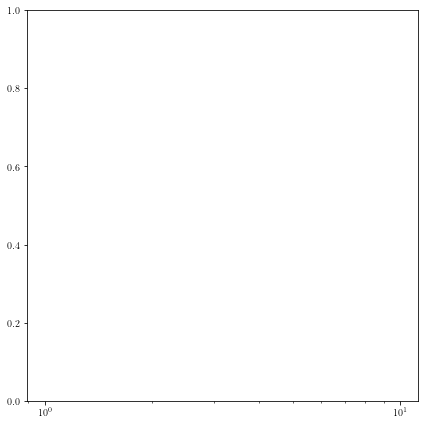

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6), layout='tight')

ax.semilogx(TNGnr[0], qdm, label=r'$\log(M) = {}$'.format(13.5))

plt.show()

In [37]:
TNG_Qdm_pct = np.percentile(qdm, 50, axis=0)

In [39]:
print(TNG_Qdm_pct)

0.8627779542927658


In [47]:
sdm = (halos_df['s_DM_noiter'].values)

In [49]:
halo_ids = (halos_df['HaloID'].values)

In [50]:
print(halo_ids.shape)

(13643,)


In [53]:
print(sdm.shape)

(13643,)
